In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR = "../data"

In [7]:
# Check exact column names before loading
import pandas as pd
import os

DATA_DIR = "../data"

prices_raw = pd.read_csv(os.path.join(DATA_DIR, "spot_prices.csv"))
print("Spot price columns:")
print(prices_raw.columns.tolist())
print()
print(prices_raw.head(3))

Spot price columns:
['HourUTC', 'HourDK', 'PriceArea', 'SpotPriceDKK', 'SpotPriceEUR']

               HourUTC               HourDK PriceArea  SpotPriceDKK  \
0  2025-07-01T22:00:00  2025-07-02 00:00:00       DK1        890.03   
1  2025-07-01T23:00:00  2025-07-02 01:00:00       DK1        766.25   
2  2025-07-02T00:00:00  2025-07-02 02:00:00       DK1        690.45   

   SpotPriceEUR  
0        119.29  
1        102.70  
2         92.54  


In [8]:
prices     = pd.read_csv(os.path.join(DATA_DIR, "spot_prices.csv"), parse_dates=["HourDK"])
production = pd.read_csv(os.path.join(DATA_DIR, "production.csv"),  parse_dates=["HourDK"])

print("Spot prices shape:  ", prices.shape)
print("Production shape:   ", production.shape)

Spot prices shape:   (2160, 5)
Production shape:    (2160, 28)


In [9]:
# What columns do we have? What do the first rows look like?
print("=== Spot Prices ===")
print(prices.dtypes)
print()
prices.head(10)

=== Spot Prices ===
HourUTC                    str
HourDK          datetime64[us]
PriceArea                  str
SpotPriceDKK           float64
SpotPriceEUR           float64
dtype: object



,HourUTC,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR
0,2025-07-01T22:00:00,2025-07-02 00:00:00,DK1,890.03,119.29
1,2025-07-01T23:00:00,2025-07-02 01:00:00,DK1,766.25,102.70
2,2025-07-02T00:00:00,2025-07-02 02:00:00,DK1,690.45,92.54
3,2025-07-02T01:00:00,2025-07-02 03:00:00,DK1,687.02,92.08
4,2025-07-02T02:00:00,2025-07-02 04:00:00,DK1,684.26,91.71
5,2025-07-02T03:00:00,2025-07-02 05:00:00,DK1,750.21,100.55
6,2025-07-02T04:00:00,2025-07-02 06:00:00,DK1,868.70,116.43
7,2025-07-02T05:00:00,2025-07-02 07:00:00,DK1,823.85,110.42
8,2025-07-02T06:00:00,2025-07-02 08:00:00,DK1,779.83,104.52
9,2025-07-02T07:00:00,2025-07-02 09:00:00,DK1,690.08,92.49


In [10]:
# Same for production — this also confirms the exact column names
print("=== Production ===")
print(production.dtypes)
print()
production.head(10)

=== Production ===
HourUTC                                  str
HourDK                        datetime64[us]
PriceArea                                str
CentralPowerMWh                      float64
LocalPowerMWh                        float64
CommercialPowerMWh                   float64
LocalPowerSelfConMWh                 float64
OffshoreWindLt100MW_MWh              float64
OffshoreWindGe100MW_MWh              float64
OnshoreWindLt50kW_MWh                float64
OnshoreWindGe50kW_MWh                float64
HydroPowerMWh                        float64
SolarPowerLt10kW_MWh                 float64
SolarPowerGe10Lt40kW_MWh             float64
SolarPowerGe40kW_MWh                 float64
SolarPowerSelfConMWh                 float64
UnknownProdMWh                       float64
ExchangeNO_MWh                       float64
ExchangeSE_MWh                       float64
ExchangeGE_MWh                       float64
ExchangeNL_MWh                       float64
ExchangeGB_MWh                      

,HourUTC,HourDK,PriceArea,CentralPowerMWh,LocalPowerMWh,CommercialPowerMWh,LocalPowerSelfConMWh,OffshoreWindLt100MW_MWh,OffshoreWindGe100MW_MWh,OnshoreWindLt50kW_MWh,OnshoreWindGe50kW_MWh,HydroPowerMWh,SolarPowerLt10kW_MWh,SolarPowerGe10Lt40kW_MWh,SolarPowerGe40kW_MWh,SolarPowerSelfConMWh,UnknownProdMWh,ExchangeNO_MWh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeNL_MWh,ExchangeGB_MWh,ExchangeGreatBelt_MWh,GrossConsumptionMWh,GridLossTransmissionMWh,GridLossInterconnectorsMWh,GridLossDistributionMWh,PowerToHeatMWh
0,2025-07-01T22:00:00,2025-07-02 00:00:00,DK1,49.34,86.10,54.78,30.78,48.27,276.01,0.16,335.45,1.19,0.39,0.08,0.06,0.00,0.40,1478.23,716.72,-348.25,-413.78,-165.88,103.00,2253.05,48.15,9.11,84.84,69.18
1,2025-07-01T23:00:00,2025-07-02 01:00:00,DK1,2.30,81.86,53.95,32.31,91.84,302.11,0.18,340.46,1.16,0.29,0.05,0.09,0.00,0.44,1532.15,716.94,-1274.04,-365.75,565.83,152.50,2234.67,52.41,7.81,84.20,66.81
2,2025-07-02T00:00:00,2025-07-02 02:00:00,DK1,3.24,93.52,55.47,38.27,91.61,339.36,0.15,386.07,1.13,0.26,0.05,0.08,0.00,0.51,1616.08,716.55,-546.37,-189.67,-525.48,226.00,2306.84,54.85,3.96,87.46,113.64
3,2025-07-02T01:00:00,2025-07-02 03:00:00,DK1,2.32,86.90,55.76,37.59,81.61,239.78,0.30,423.39,1.14,0.26,0.04,0.27,0.00,0.88,1404.31,716.68,-570.91,-425.04,-161.88,313.80,2207.20,56.31,9.49,82.53,63.85
4,2025-07-02T02:00:00,2025-07-02 04:00:00,DK1,4.26,98.34,58.02,34.45,34.65,143.95,0.22,309.53,1.16,0.26,0.05,2.61,0.15,0.74,1613.83,716.73,-750.94,-490.81,16.84,348.20,2142.23,53.49,11.53,79.93,69.71
5,2025-07-02T03:00:00,2025-07-02 05:00:00,DK1,2.25,85.75,56.80,42.51,19.69,228.08,0.68,275.35,1.13,1.08,0.24,49.88,2.56,0.96,1390.72,695.30,-1121.57,-492.39,482.14,428.30,2149.44,47.77,11.59,76.79,98.01
6,2025-07-02T04:00:00,2025-07-02 06:00:00,DK1,2.67,90.29,57.52,63.57,16.04,456.39,0.36,254.12,1.13,8.92,1.79,160.76,18.46,0.73,1322.23,670.33,-898.62,-492.32,628.15,110.90,2473.42,48.98,11.62,82.98,171.90
7,2025-07-02T05:00:00,2025-07-02 07:00:00,DK1,5.64,91.87,65.81,84.70,21.93,294.65,0.32,166.35,1.15,27.78,4.39,475.19,25.37,0.80,1361.67,701.15,-1107.47,-492.18,574.35,429.40,2732.87,55.35,11.61,89.98,112.22
8,2025-07-02T06:00:00,2025-07-02 08:00:00,DK1,4.23,91.92,60.36,126.16,16.04,145.69,0.56,110.69,1.15,62.20,9.84,853.70,46.29,0.99,1521.96,710.01,-379.11,-487.78,-234.83,281.30,2941.37,60.54,11.49,95.75,87.33
9,2025-07-02T07:00:00,2025-07-02 09:00:00,DK1,4.96,124.20,55.88,133.42,19.62,304.50,1.43,152.54,1.13,91.96,15.01,1126.26,61.66,0.72,1615.48,685.51,-525.14,-285.25,-806.58,261.50,3038.82,58.44,5.96,99.55,88.11


In [11]:
print("Missing values — Prices:")
print(prices.isnull().sum())
print()
print("Missing values — Production:")
print(production.isnull().sum())

Missing values — Prices:
HourUTC         0
HourDK          0
PriceArea       0
SpotPriceDKK    0
SpotPriceEUR    0
dtype: int64

Missing values — Production:
HourUTC                       0
HourDK                        0
PriceArea                     0
CentralPowerMWh               0
LocalPowerMWh                 0
CommercialPowerMWh            0
LocalPowerSelfConMWh          0
OffshoreWindLt100MW_MWh       0
OffshoreWindGe100MW_MWh       0
OnshoreWindLt50kW_MWh         0
OnshoreWindGe50kW_MWh         0
HydroPowerMWh                 0
SolarPowerLt10kW_MWh          0
SolarPowerGe10Lt40kW_MWh      0
SolarPowerGe40kW_MWh          0
SolarPowerSelfConMWh          0
UnknownProdMWh                0
ExchangeNO_MWh                0
ExchangeSE_MWh                0
ExchangeGE_MWh                0
ExchangeNL_MWh                0
ExchangeGB_MWh                0
ExchangeGreatBelt_MWh         0
GrossConsumptionMWh           0
GridLossTransmissionMWh       0
GridLossInterconnectorsMWh    0
GridLossDi

In [12]:
print("Spot Prices summary:")
display(prices[["SpotPriceEUR"]].describe())

print("\nProduction summary:")
display(production.describe())

Spot Prices summary:


,SpotPriceEUR
count,2160.00
mean,74.92
std,48.24
min,-38.14
25%,40.55
50%,85.44
75%,102.71
max,413.66



Production summary:


,HourDK,CentralPowerMWh,LocalPowerMWh,CommercialPowerMWh,LocalPowerSelfConMWh,OffshoreWindLt100MW_MWh,OffshoreWindGe100MW_MWh,OnshoreWindLt50kW_MWh,OnshoreWindGe50kW_MWh,HydroPowerMWh,SolarPowerLt10kW_MWh,SolarPowerGe10Lt40kW_MWh,SolarPowerGe40kW_MWh,SolarPowerSelfConMWh,UnknownProdMWh,ExchangeNO_MWh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeNL_MWh,ExchangeGB_MWh,ExchangeGreatBelt_MWh,GrossConsumptionMWh,GridLossTransmissionMWh,GridLossInterconnectorsMWh,GridLossDistributionMWh,PowerToHeatMWh
count,2160,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00,2160.00
mean,2025-08-15 23:30:00,51.04,99.09,46.95,97.02,71.51,503.76,3.21,737.06,1.29,52.46,9.11,470.29,30.69,1.01,826.81,223.56,-476.87,88.10,-174.94,-47.72,2613.43,60.66,15.00,97.99,176.13
min,2025-07-02 00:00:00,0.00,29.26,22.54,24.89,0.00,0.00,0.00,0.56,1.01,0.12,0.02,0.01,0.00,0.00,-1453.27,-728.49,-2497.98,-704.25,-1454.13,-607.90,1645.07,0.87,0.00,47.70,13.50
25%,2025-07-24 11:45:00,2.04,77.72,40.62,48.82,24.59,200.90,0.51,270.39,1.16,0.36,0.10,3.01,0.19,0.69,319.80,0.00,-1482.59,-370.23,-995.51,-259.35,2206.67,50.80,7.71,84.20,58.97
50%,2025-08-15 23:30:00,3.16,89.62,46.57,71.27,53.60,423.20,1.85,587.42,1.25,7.71,1.68,164.48,11.74,1.02,1081.93,297.19,-601.32,76.47,-330.17,-68.70,2575.06,60.81,15.12,95.03,99.76
75%,2025-09-07 11:15:00,35.84,108.80,52.41,142.50,105.04,784.09,5.03,1041.98,1.40,95.25,16.11,855.64,55.71,1.32,1452.09,336.94,299.45,595.87,733.99,189.10,3006.84,72.89,19.35,105.82,228.29
max,2025-09-29 23:00:00,871.02,470.45,91.99,258.86,232.56,1358.06,14.56,2644.18,1.82,302.73,53.42,2427.97,276.56,2.78,1622.25,717.85,2487.88,684.34,1068.64,587.70,4229.66,175.03,67.36,219.17,1096.92
std,NaN,112.30,37.31,9.78,58.45,60.53,363.01,3.45,594.27,0.15,71.39,12.37,572.97,38.73,0.45,742.48,320.63,1228.14,485.90,863.19,283.63,503.30,23.36,9.92,20.01,177.30


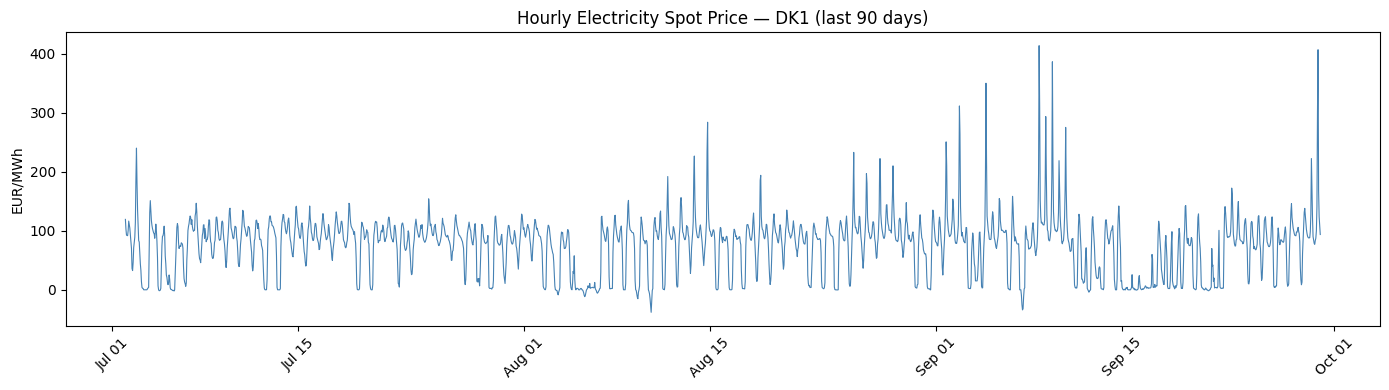

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prices["HourDK"], prices["SpotPriceEUR"], linewidth=0.8, color="steelblue")
ax.set_title(f"Hourly Electricity Spot Price — DK1 (last 90 days)")
ax.set_ylabel("EUR/MWh")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

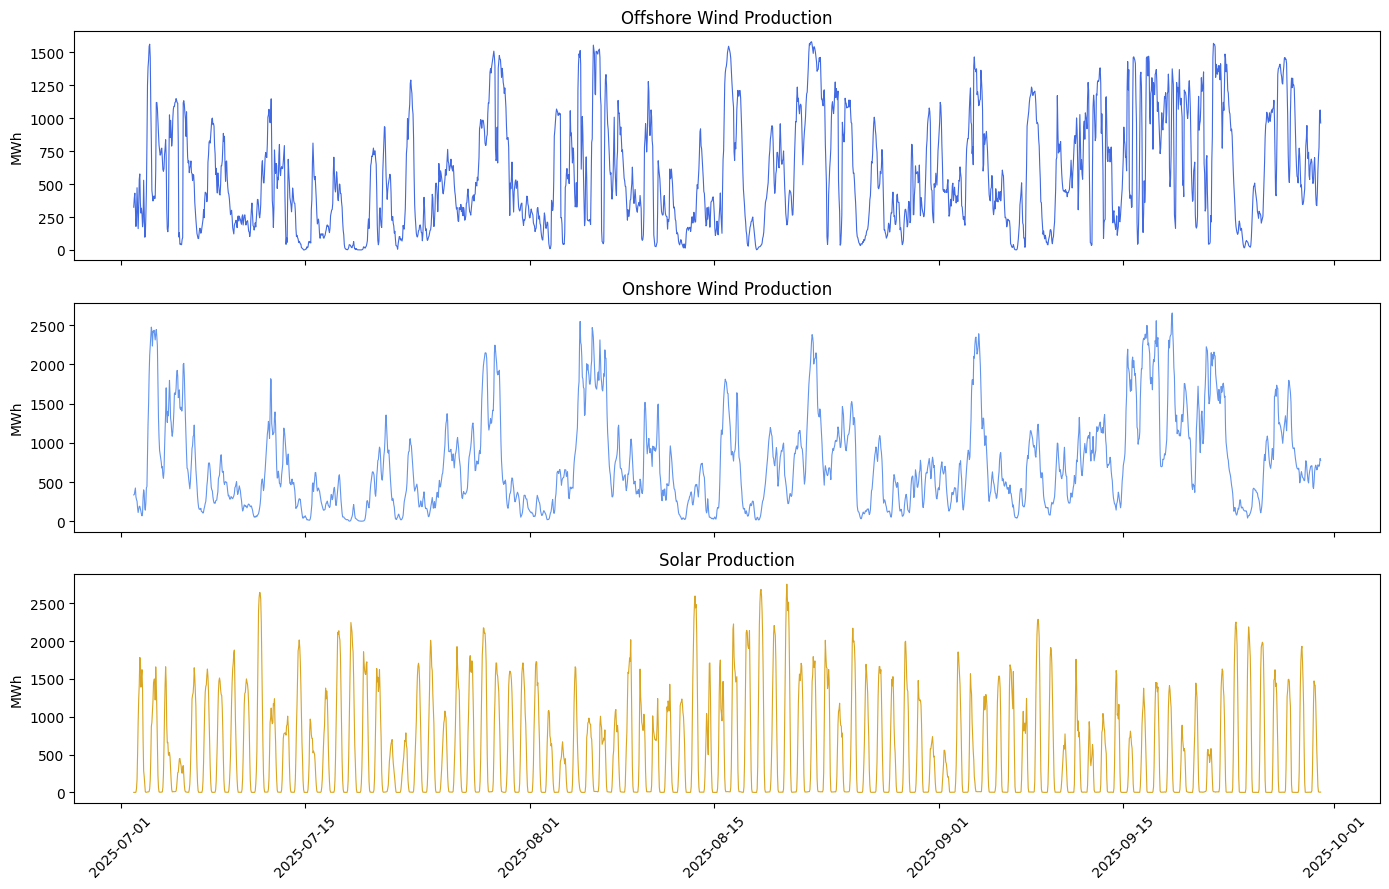

In [14]:
production["OffshoreWind"] = production["OffshoreWindLt100MW_MWh"] + production["OffshoreWindGe100MW_MWh"]
production["OnshoreWind"]  = production["OnshoreWindLt50kW_MWh"]   + production["OnshoreWindGe50kW_MWh"]
production["Solar"]        = (production["SolarPowerLt10kW_MWh"] 
                              + production["SolarPowerGe10Lt40kW_MWh"] 
                              + production["SolarPowerGe40kW_MWh"])

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(production["HourDK"], production["OffshoreWind"], color="royalblue", linewidth=0.8)
axes[0].set_ylabel("MWh")
axes[0].set_title("Offshore Wind Production")

axes[1].plot(production["HourDK"], production["OnshoreWind"], color="cornflowerblue", linewidth=0.8)
axes[1].set_ylabel("MWh")
axes[1].set_title("Onshore Wind Production")

axes[2].plot(production["HourDK"], production["Solar"], color="goldenrod", linewidth=0.8)
axes[2].set_ylabel("MWh")
axes[2].set_title("Solar Production")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
combined = pd.merge(
    prices[["HourDK", "SpotPriceEUR"]],
    production[["HourDK", "OffshoreWind", "OnshoreWind", "Solar", "GrossConsumptionMWh"]],
    on="HourDK",
    how="inner"
)

combined["TotalWind"] = combined["OffshoreWind"] + combined["OnshoreWind"]

print(f"Combined dataset: {combined.shape[0]} rows, {combined.shape[1]} columns")
print(f"Date range: {combined['HourDK'].min()} → {combined['HourDK'].max()}")
combined.head()

Combined dataset: 2160 rows, 7 columns
Date range: 2025-07-02 00:00:00 → 2025-09-29 23:00:00


,HourDK,SpotPriceEUR,OffshoreWind,OnshoreWind,Solar,GrossConsumptionMWh,TotalWind
0,2025-07-02 00:00:00,119.29,324.28,335.60,0.53,2253.05,659.89
1,2025-07-02 01:00:00,102.70,393.95,340.64,0.43,2234.67,734.59
2,2025-07-02 02:00:00,92.54,430.97,386.21,0.40,2306.84,817.19
3,2025-07-02 03:00:00,92.08,321.40,423.70,0.57,2207.20,745.09
4,2025-07-02 04:00:00,91.71,178.61,309.75,2.92,2142.23,488.36
